<h3 style="color: white; 
           text-align: center; 
           font-size: 25px;
           margin-top: 50px; 
           background-color: black; 
           border: 3px solid aqua; 
           border-radius: 9px; 
           padding: 20px;">
    Dog 🐶 vs Cat 🐈 Classifier using <span style="color: #E94E77;">LENET</span> and <span style="color: #E94E77;">RESNET</span>
</h3>

In [101]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow
import keras
from keras import Sequential
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

### 📌 Keras Generator
`Since our data is too big to load into the ram we have to use generator`

In [72]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/kaggle/input/dogs-vs-cats/train",
    labels = 'inferred',
    label_mode = 'int',
    batch_size=32, 
    image_size=(256, 256)
)

valid_ds = keras.utils.image_dataset_from_directory(
    directory = "/kaggle/input/dogs-vs-cats/test",
    labels = 'inferred',
    label_mode = 'int',
    batch_size=32, 
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


### 📌 Image Normalization

In [73]:
def process(image, label):
    image = tensorflow.cast(image/255, tensorflow.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = valid_ds.map(process)

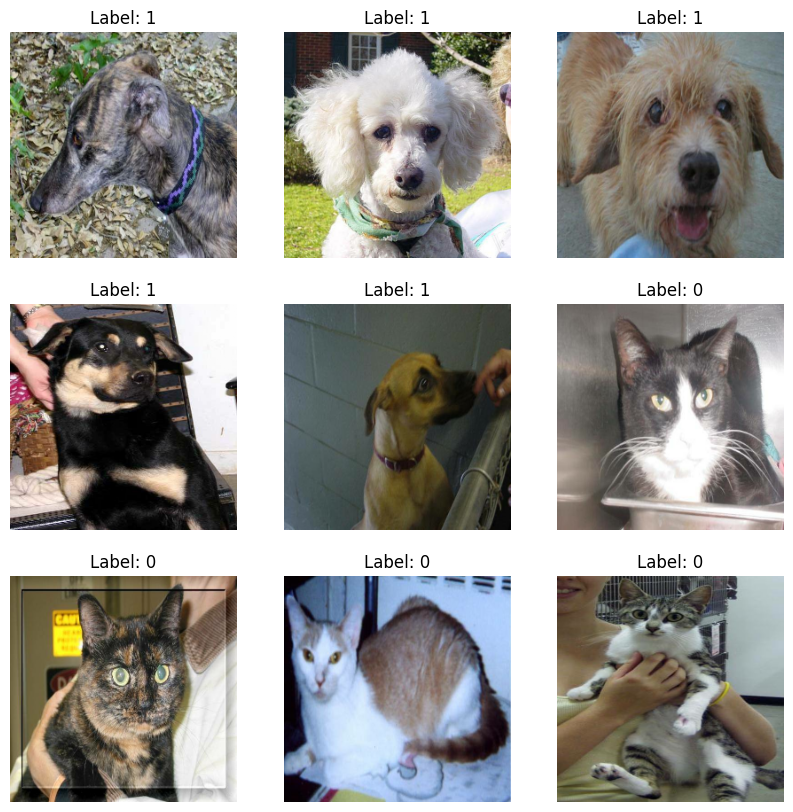

In [74]:
# Get a batch of images and labels
for images, labels in train_ds.take(1):
    break

# Display some images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy()) # Convert tensor to numpy array for plotting
    plt.title('Label: {}'.format(labels[i].numpy()))
    plt.axis('off')
plt.show()

### 📌 LeNET Model

In [75]:
LeNET = Sequential()

LeNET.add(Input(shape = (256, 256, 3,)))

LeNET.add(Conv2D(filters = 6, kernel_size = (5,5), strides = 1, activation = 'tanh'))
LeNET.add(MaxPooling2D(pool_size = (2,2), strides = 2))

LeNET.add(Conv2D(filters = 16, kernel_size = (5,5), strides = 1, activation = 'tanh'))
LeNET.add(MaxPooling2D(pool_size = (2,2), strides = 2))

LeNET.add(Flatten())

LeNET.add(Dense(units = 120, activation = 'tanh'))
LeNET.add(Dense(units = 84, activation = 'tanh'))
LeNET.add(Dense(units = 1, activation = 'sigmoid'))

In [76]:
LeNET.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 252, 252, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 126, 126, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 122, 122, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 120)            │     7,144,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,157,561 (27.30 MB)

 Trainable params: 7,157,561 (27.30 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
LeNET.compile(loss = "binary_crossentropy", optimizer = 'adam', metrics = ['accuracy'])

In [78]:
history = LeNET.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5021 - loss: 0.7751 - val_accuracy: 0.5000 - val_loss: 0.6989
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.5005 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5060 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5038 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.4954 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5017 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5039 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.5043 - loss: 0.6952 - 

### 📌 Data Augmentation

In [81]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [82]:
train_generator = datagen.flow_from_directory(
    '/kaggle/input/dogs-vs-cats/train',  # this is the target directory
    target_size=(256, 256), 
    batch_size=32,
    class_mode='binary'
)  # since we use binary_crossentropy loss, we need binary labels

validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/dogs-vs-cats/test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


### 📌 Creating our own CNN Archetecture 
`Additional Dropout Layers and BatchNormalization`

In [89]:
# Creating CNN Model
model = Sequential()

model.add(Input(shape = (256, 256, 3,)))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'valid', activation = 'relu', strides = (1,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'valid', activation = 'relu', strides = (1,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = 'valid', activation = 'relu', strides = (1,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(units = 1, activation = 'sigmoid'))

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │    29,491,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,872,257 (113.95 MB)

 Trainable params: 29,871,361 (113.95 MB)

 Non-trainable params: 896 (3.50 KB)

In [90]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [91]:
history = model.fit(
    train_generator, 
    steps_per_epoch = 2000 // 32,
    epochs = 10, 
    validation_data = validation_generator
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 62s 679ms/step - accuracy: 0.5287 - loss: 14.8459 - val_accuracy: 0.4786 - val_loss: 10.3374
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 644ms/step - accuracy: 0.5294 - loss: 12.4422 - val_accuracy: 0.5006 - val_loss: 2.7694
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 669ms/step - accuracy: 0.5188 - loss: 4.1362 - val_accuracy: 0.4786 - val_loss: 2.0828
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 628ms/step - accuracy: 0.5350 - loss: 2.2848 - val_accuracy: 0.5300 - val_loss: 1.2818
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 578ms/step - accuracy: 0.5478 - loss: 1.1066 - val_accuracy: 0.5448 - val_loss: 0.8472
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 532ms/step - accuracy: 0.5421 - loss: 0.9250 - val_accuracy: 0.5622 - val_loss: 0.8854
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 540ms/step - accuracy: 0.5973 - loss: 0.7879 - val_accuracy: 0.5564 - val_loss: 0.6942
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 539ms/step - accuracy: 0.5641 - loss: 0.7105 - val_a

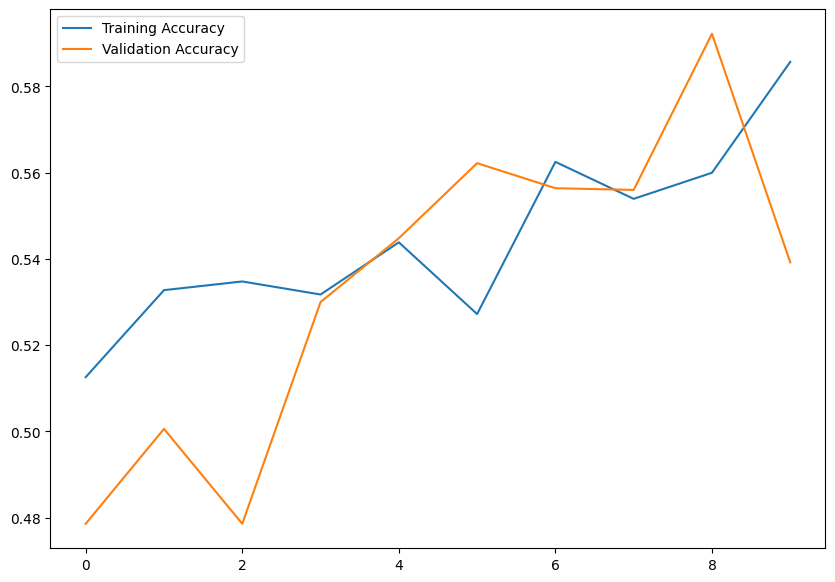

In [94]:
plt.figure(figsize = (10, 7))
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.xlabel("no. epochs")
plt.ylabel("accuracy")
plt.show()

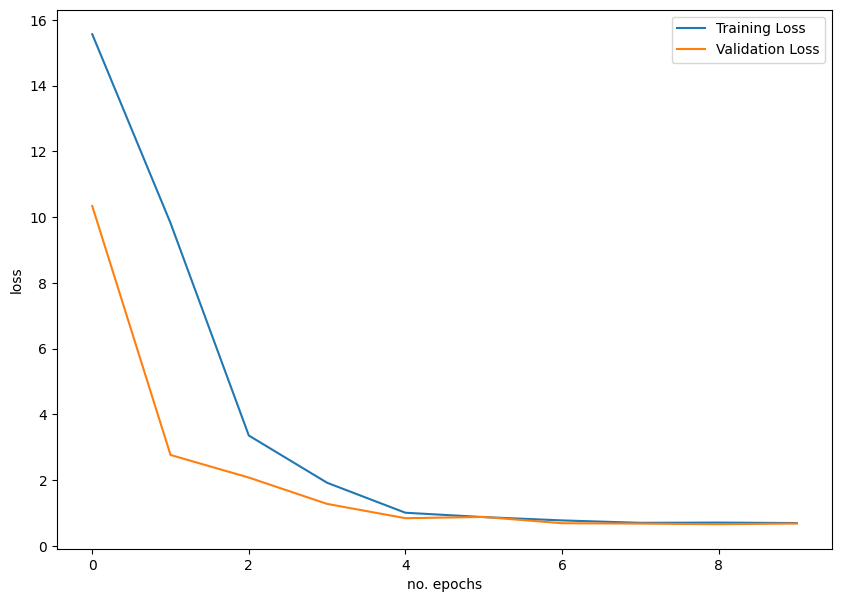

In [95]:
plt.figure(figsize = (10, 7))
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.legend()
plt.xlabel("no. epochs")
plt.ylabel("loss")
plt.show()

🚧 Working on it...

### 📌 Model Testing

In [99]:
image = keras.utils.load_img(
    path = "/kaggle/input/dogs-vs-cats/test/cats/cat.10.jpg",
    color_mode="rgb",
    target_size=(256, 256, 3),
    interpolation="nearest",
    keep_aspect_ratio=False,
)

input_arr = keras.utils.img_to_array(image)
input_arr = np.array([input_arr])
prediction = 'Cat' if model.predict(input_arr) <= 0.5 else 'Dog' # Since I Used sigmoid activation which results the probability between 0 to 1 (Threshold = 0.5)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


'Cat'

In [100]:
image = keras.utils.load_img(
    path = "/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg",
    color_mode="rgb",
    target_size=(256, 256, 3),
    interpolation="nearest",
    keep_aspect_ratio=False,
)

input_arr = keras.utils.img_to_array(image)
input_arr = np.array([input_arr])
prediction = 'Cat' if model.predict(input_arr) <= 0.5 else 'Dog'
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


'Dog'

### 📌 ResNET Model

In [116]:
model = tensorflow.keras.applications.ResNet50(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax"
)

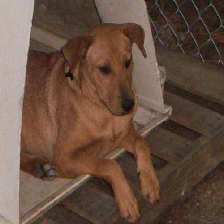

In [117]:
img = keras.utils.load_img('/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg', target_size = (224, 224))
img

In [118]:
img = keras.utils.img_to_array(img)
x = np.expand_dims(img, axis = 0)
x = preprocess_input(x)

In [119]:
preds = model.predict(x)
print(decode_predictions(preds, top = 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[('n02087394', 'Rhodesian_ridgeback', 0.6518403), ('n02093991', 'Irish_terrier', 0.18409845), ('n02090379', 'redbone', 0.10455019)]]


📌 `Rhodesian Ridgebacks` and `Irish Terriers` closely resemble the dog shown in the image.


In [120]:
preds.shape # 1000 Classes

(1, 1000)